# Exploratory Data Analysis (EDA)
This notebook visualizes sales distributions, trends, and differences across provinces and distributors, while highlighting data quality issues.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Setting aesthetic parameters for Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [2]:
data_path = '../data/bronze/'
transactions = pd.read_csv(os.path.join(data_path, 'transactions_history_final.csv'))
outlet_master = pd.read_csv(os.path.join(data_path, 'outlet_master.csv'))

# Merge for enriched analysis
df = transactions.merge(outlet_master, on='Outlet_ID', how='left')

# Extract Province from Distributor_ID
province_map = {
    'W': 'Western',
    'C': 'Central',
    'S': 'Southern',
    'NW': 'North Western',
    'E': 'Eastern',
    'NC': 'North Central',
    'U': 'Uva',
    'SG': 'Sabaragamuwa',
    'N': 'Northern'
}

def extract_province(dist_id):
    parts = dist_id.split('_')
    if len(parts) > 1:
        code = parts[1]
        return province_map.get(code, 'Other')
    return 'Unknown'

df['Province'] = df['Distributor_ID'].apply(extract_province)

print(f"Data loaded and enriched. Shape: {df.shape}")

Data loaded and enriched. Shape: (2376389, 11)


## 2. Sales Distributions

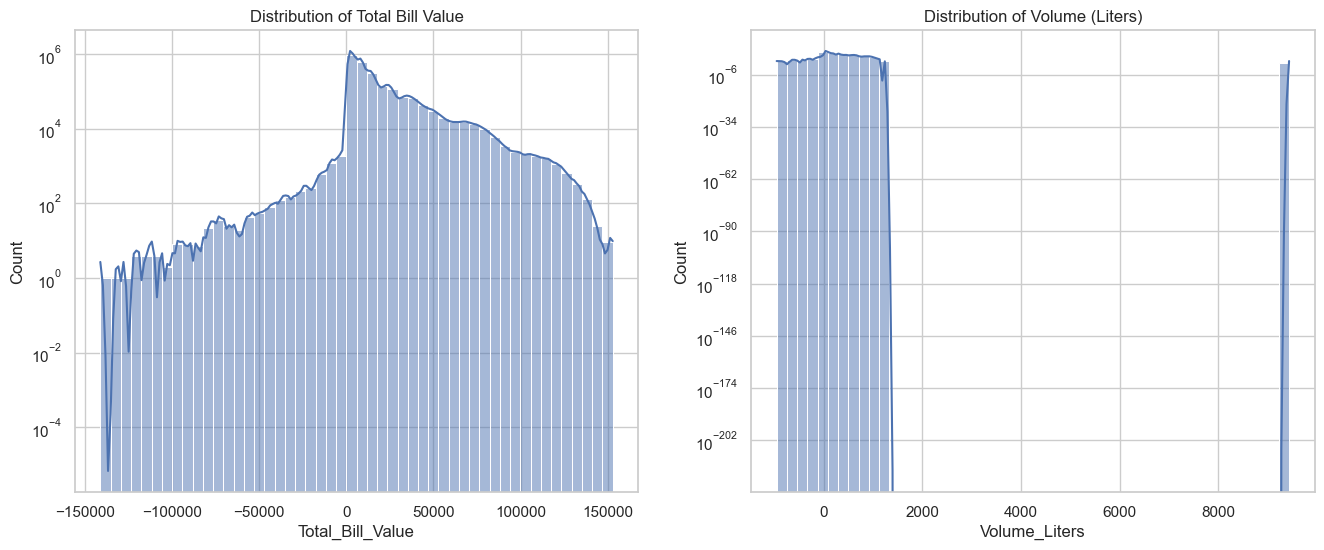

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Total_Bill_Value'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of Total Bill Value')
ax[0].set_yscale('log') # Using log scale for better visibility if skewed

sns.histplot(df['Volume_Liters'], bins=50, ax=ax[1], kde=True)
ax[1].set_title('Distribution of Volume (Liters)')
ax[1].set_yscale('log')

plt.show()

## 3. Outliers Analysis

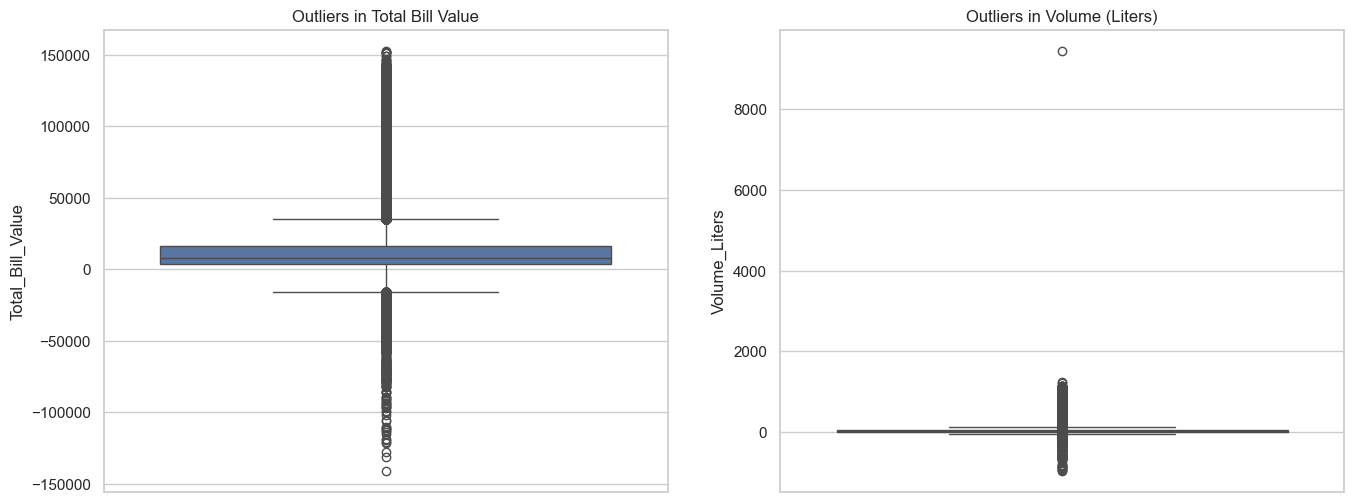

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(y=df['Total_Bill_Value'], ax=ax[0])
ax[0].set_title('Outliers in Total Bill Value')

sns.boxplot(y=df['Volume_Liters'], ax=ax[1])
ax[1].set_title('Outliers in Volume (Liters)')

plt.show()

## 4. Monthly Trends

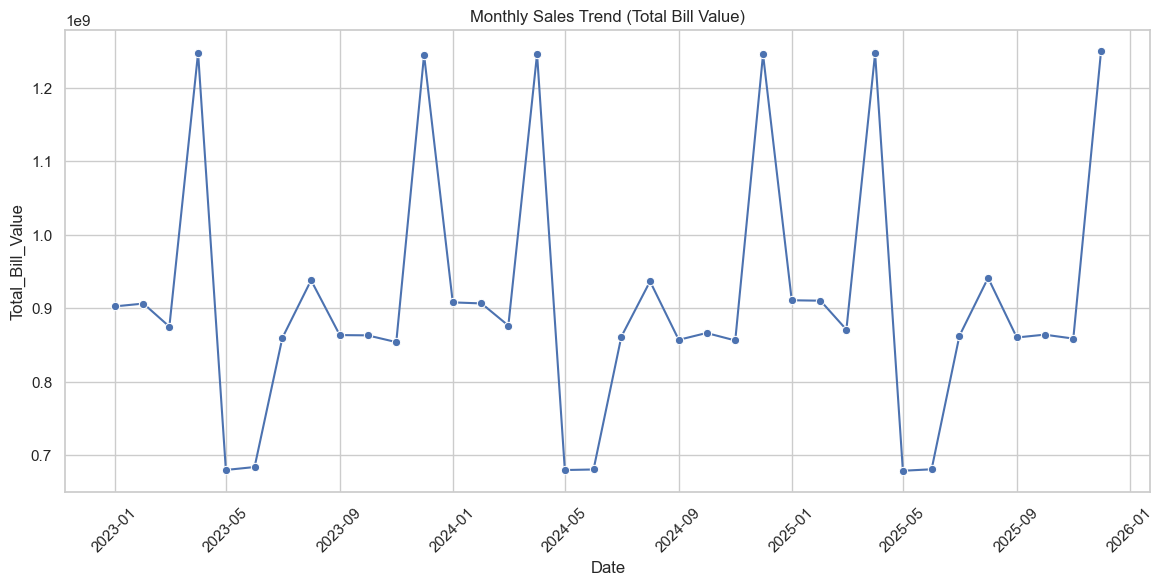

In [5]:
# Group by Year and Month
monthly_sales = df.groupby(['Year', 'Month'])['Total_Bill_Value'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))
monthly_sales = monthly_sales.sort_values('Date')

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Date', y='Total_Bill_Value', marker='o')
plt.title('Monthly Sales Trend (Total Bill Value)')
plt.xticks(rotation=45)
plt.show()

## 5. Province Differences

C:\Users\user\AppData\Local\Temp\ipykernel_22464\953625945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_sales, x='Total_Bill_Value', y='Province', palette='viridis')


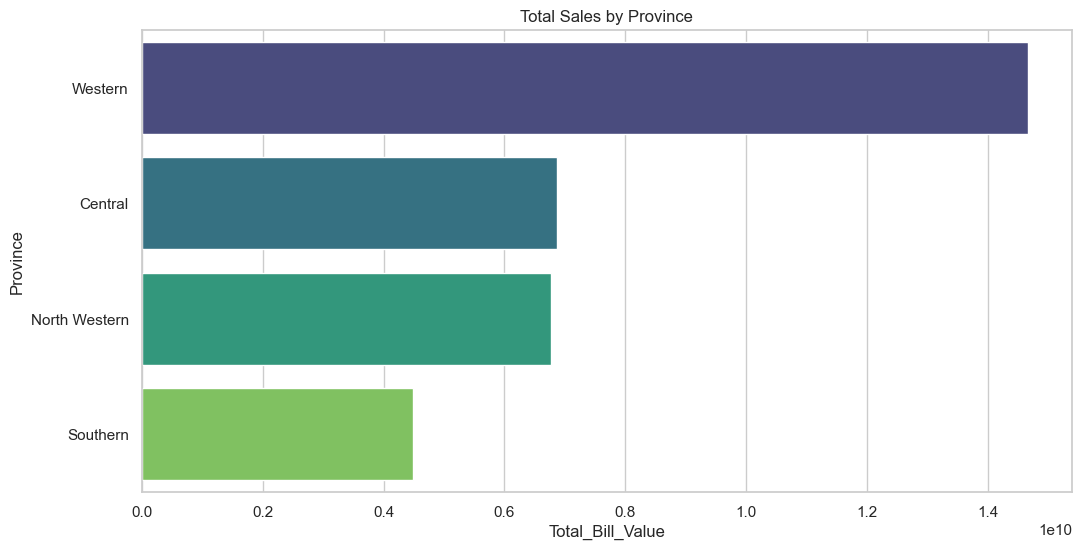

In [6]:
province_sales = df.groupby('Province')['Total_Bill_Value'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=province_sales, x='Total_Bill_Value', y='Province', palette='viridis')
plt.title('Total Sales by Province')
plt.show()

## 6. Distributor Differences

C:\Users\user\AppData\Local\Temp\ipykernel_22464\1640055906.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distributor_sales, x='Total_Bill_Value', y='Distributor_ID', palette='magma')


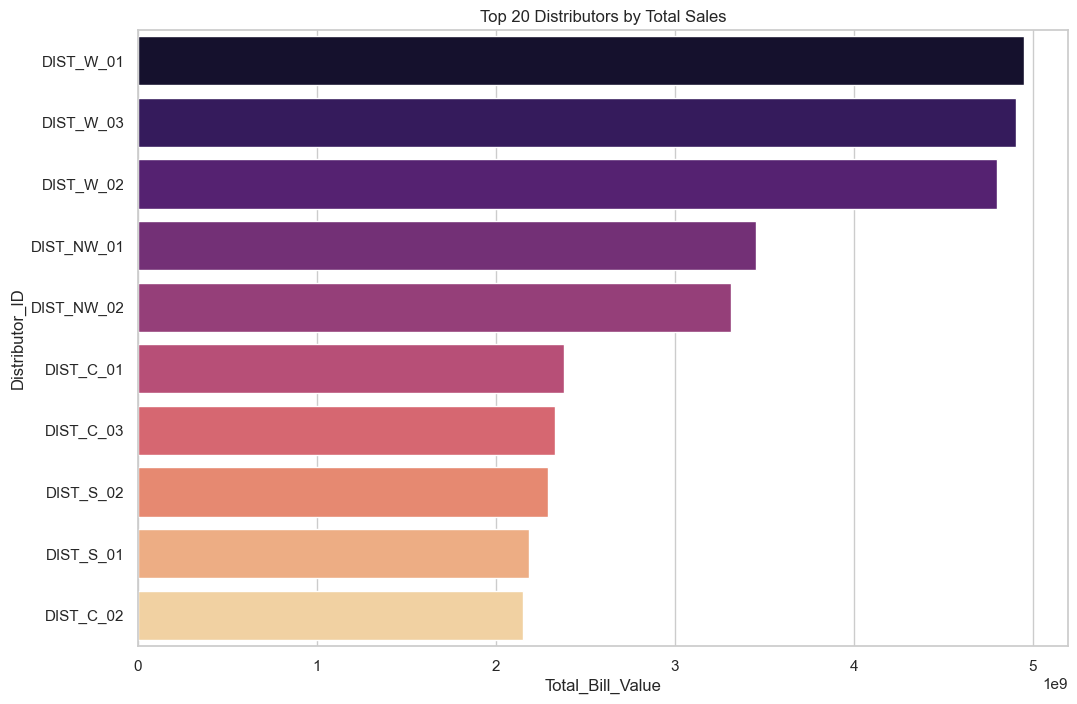

In [7]:
distributor_sales = df.groupby('Distributor_ID')['Total_Bill_Value'].sum().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=distributor_sales, x='Total_Bill_Value', y='Distributor_ID', palette='magma')
plt.title('Top 20 Distributors by Total Sales')
plt.show()

## 7. Data Quality Issues Visualization

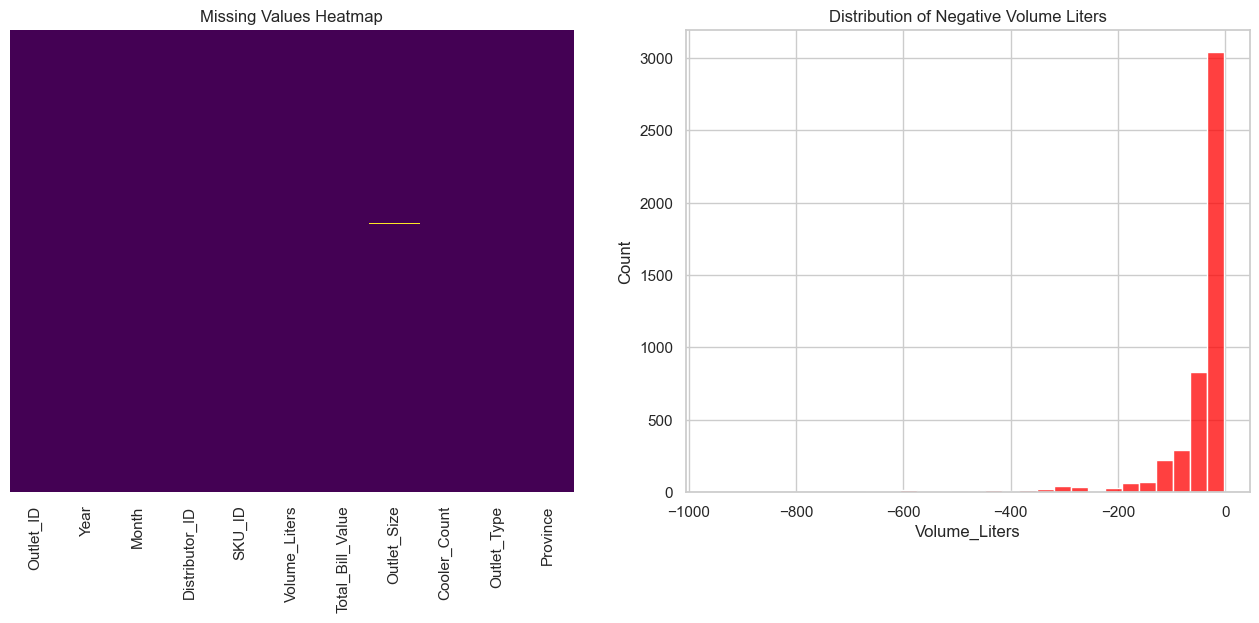

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visualization of Missing Values
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax[0])
ax[0].set_title('Missing Values Heatmap')

# Visualization of Negative Volumes
negative_vols = df[df['Volume_Liters'] < 0]
if not negative_vols.empty:
    sns.histplot(negative_vols['Volume_Liters'], bins=30, color='red', ax=ax[1])
    ax[1].set_title('Distribution of Negative Volume Liters')
else:
    ax[1].text(0.5, 0.5, 'No Negative Volumes Found', ha='center', va='center')

plt.show()